In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time
import os
from sklearn.preprocessing import MinMaxScaler


In [2]:
# Graphic Style

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12,5)

In [3]:
#Loading consolidated Dataset

COLUMN_SCHEMA = {
    "Czas": "str",
    "Czas2": "str",
    "Pressure - leak line":     "float64",
    "Temperature - leak line":  "float64",
    "Pressure - output":        "float64",
    "Temperature - suction line": "float64",
    "Temperature - output":     "float64",
    "Flow - leak line":         "float64",
    "Flow - output":            "float64",
    "Temp. diff":               "float64",
    "stan":                     "int64",
    "label":                    "int",
    "label_name":               "str",    
}
df = pd.read_csv("../data/processed/dataset_merged.csv", dtype=COLUMN_SCHEMA)

#df.head()

In [4]:
#df.head()
df.describe()

,Pressure - leak line,Temperature - leak line,Pressure - output,Temperature - suction line,Temperature - output,Flow - leak line,Flow - output,Temp. diff,stan,label
count,153205.000000,153205.000000,153205.000000,153205.000000,153205.000000,153205.000000,146359.000000,153205.000000,153205.000000,153205.000000
mean,0.194556,48.450534,137.187991,34.368517,36.156113,1.742112,61.302737,14.082017,0.553885,0.862472
std,0.045841,7.548650,76.776411,8.725532,8.849674,1.366422,11.475802,4.084872,0.497090,0.975103
min,0.000000,0.000000,-4.627143,0.000000,0.000000,-0.367347,-0.912105,-7.902500,0.000000,0.000000
25%,0.162083,44.490714,64.599375,28.149412,30.151111,0.262308,61.998125,11.690870,0.000000,0.000000
50%,0.194375,48.750000,152.381190,34.754792,36.430000,1.696047,63.185909,13.849512,1.000000,1.000000
75%,0.225641,54.004138,197.194667,41.768718,43.478947,2.737500,64.931708,16.891316,1.000000,1.000000
max,0.451111,63.754857,294.052308,50.419020,53.285490,6.258444,67.602821,24.748929,1.000000,3.000000


            label_name  count  percentual
0               NORMAL  68347       44.61
1  SIMULATED FAILURE 1  14333        9.36
2  SIMULATED FAILURE 2  16472       10.75
3     VALVE PLATE WEAR  54053       35.28


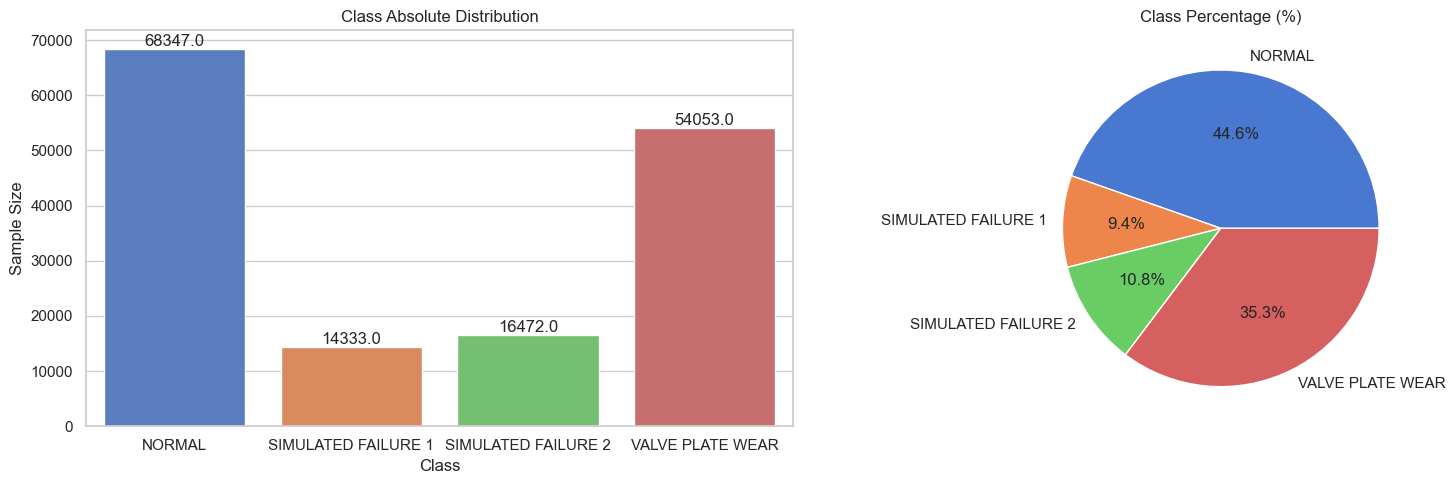

In [5]:
#COUNTING ABSOLUTE %

class_dist = df.groupby("label_name").size().reset_index(name="count")
class_dist["percentual"] = (class_dist["count"] / len(df) * 100).round(2)
print(class_dist)

#GRAPH

fig, axes = plt.subplots(1, 2, figsize=(16,5))

#GRAPHIC 1

barras = sns.barplot(
    data=class_dist,
    x="label_name",
    y="count",
    ax=axes[0],
    hue="label_name",
    legend=False
)
axes[0].set_title("Class Absolute Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Sample Size")

for p in barras.containers:
    barras.bar_label(p, fmt='%.1f', label_type="edge" )

#GRAPHIC 2 - (Pizza)

axes[1].pie(
    class_dist["count"],
    labels=class_dist["label_name"],
    autopct="%1.1f%%", #SHOWS THE PERCENTAGE IN EACH PIECE
)

axes[1].set_title("Class Percentage (%)")

plt.tight_layout()
plt.savefig("reports/class_distribution.png", dpi=150)
plt.show()



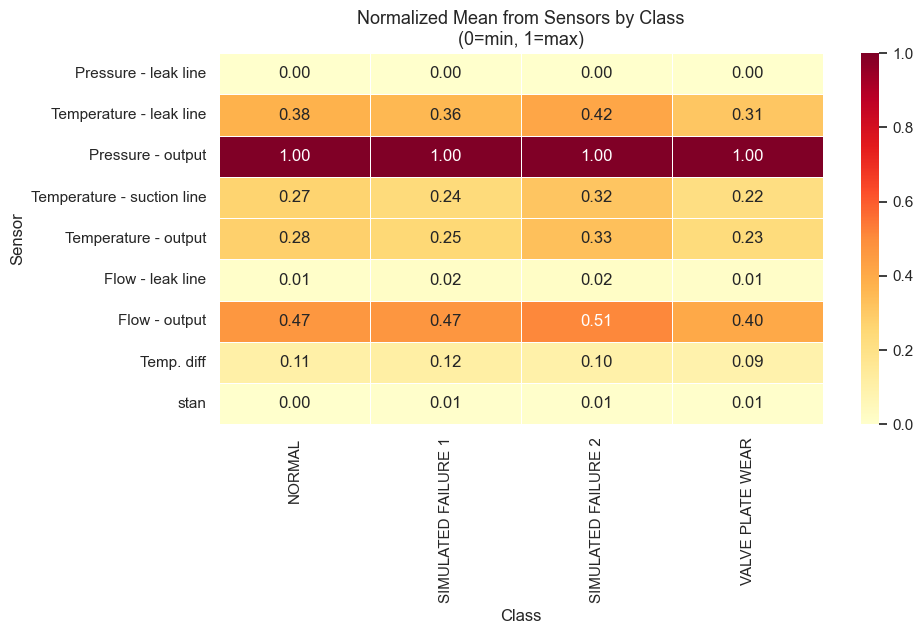

In [6]:
cols_to_drop = ["label_name", "label", "Czas", "Czas2"]
feature_cols = [col for col in df.columns if col not in cols_to_drop]

#CALCULA THE MEAN FOR EACH SENSOR BY CLASS
#NORMALIZE 0 AND 1

stats = df.groupby("label_name")[feature_cols].mean()

#NORMALIZATION

scaler = MinMaxScaler()
stats_normalized = pd.DataFrame(
    scaler.fit_transform(stats.T), #Transpose: features in lines
    index=feature_cols,
    columns=stats.index
)

fig, ax = plt.subplots(figsize=(10, len(feature_cols) * 0.5 + 2))

sns.heatmap(
    stats_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Normalized Mean from Sensors by Class\n(0=min, 1=max)", fontsize=13)
ax.set_xlabel("Class")
ax.set_ylabel("Sensor")
plt.tight_layout()
plt.savefig("reports/sensor_mean_heatmap.png", dpi=150)
plt.show()

--PAY ATTENTION AT THE PRESSURE - OUTPUT AND TEMP. DIFF

In [7]:
# OUTLIERS DETECTION BY USING IQR

print("="*55)
print("OUTLIERS BY SENSOR AND CLASS (IQR METHODOLOGY)")
print('='*55)

outlier_report = []

for classe in df["label_name"].unique():
    subset = df[df['label_name'] == classe][feature_cols]
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1

    outliers = ((subset < Q1 - 1.5 * IQR) | (subset > Q3 + 1.5 * IQR)).sum()

    for feature in feature_cols:
        n_outliers = outliers[feature]
        pct = round(n_outliers / len(subset) * 100, 2)
        if n_outliers > 0:
            outlier_report.append({
                "class": classe,
                "sensor": feature,
                "outliers": n_outliers,
                "percentage": pct
            })
outlier_df = (
    pd.DataFrame(outlier_report)
    .sort_values("percentage", ascending=False)
)

print(outlier_df.to_string(index=False))

OUTLIERS BY SENSOR AND CLASS (IQR METHODOLOGY)
              class                     sensor  outliers  percentage
SIMULATED FAILURE 2 Temperature - suction line      2588       15.71
SIMULATED FAILURE 2    Temperature - leak line      2330       14.15
SIMULATED FAILURE 2       Temperature - output      2123       12.89
             NORMAL              Flow - output      4734        6.93
   VALVE PLATE WEAR    Temperature - leak line      3159        5.84
SIMULATED FAILURE 2                 Temp. diff       819        4.97
   VALVE PLATE WEAR       Temperature - output      2239        4.14
   VALVE PLATE WEAR Temperature - suction line      2114        3.91
             NORMAL                 Temp. diff      2331        3.41
   VALVE PLATE WEAR                 Temp. diff      1719        3.18
   VALVE PLATE WEAR              Flow - output      1516        2.80
             NORMAL    Temperature - leak line       905        1.32
             NORMAL           Flow - leak line       524

In [8]:

print("="*50)
print("DATA QUALITY")
print("="*50)

# NULL VALUES
nulls = df[feature_cols].isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
null_report = pd.DataFrame({"nulos": nulls, "percentual_%": null_pct})
null_report = null_report[null_report["nulos"] > 0]

if null_report.empty:
    print("\n Nenhum valor nulo encontrado nas features")
else:
    print("\n Features com valores nulos:")
    print(null_report.to_string())

# 2. Valores constantes (variância zero — inúteis para o modelo)
zero_var = df[feature_cols].std()[df[feature_cols].std() == 0]
if zero_var.empty:
    print("\n Nenhuma feature com variância zero")
else:
    print(f"\n Features constantes (remover): {list(zero_var.index)}")

# 3. Duplicatas
n_dupl = df.duplicated().sum()
print(f"\n{'' if n_dupl == 0 else ''} Linhas duplicadas: {n_dupl:,}")

# 4. Range dos valores por sensor
print("\n Range dos sensores (min → max):")
ranges = pd.DataFrame({
    "min":  df[feature_cols].min(),
    "max":  df[feature_cols].max(),
    "mean": df[feature_cols].mean().round(3),
    "std":  df[feature_cols].std().round(3)
})
print(ranges.to_string())


DATA QUALITY

 Features com valores nulos:
               nulos  percentual_%
Flow - output   6846          4.47

 Nenhuma feature com variância zero

 Linhas duplicadas: 0

 Range dos sensores (min → max):
                                 min         max     mean     std
Pressure - leak line        0.000000    0.451111    0.195   0.046
Temperature - leak line     0.000000   63.754857   48.451   7.549
Pressure - output          -4.627143  294.052308  137.188  76.776
Temperature - suction line  0.000000   50.419020   34.369   8.726
Temperature - output        0.000000   53.285490   36.156   8.850
Flow - leak line           -0.367347    6.258444    1.742   1.366
Flow - output              -0.912105   67.602821   61.303  11.476
Temp. diff                 -7.902500   24.748929   14.082   4.085
stan                        0.000000    1.000000    0.554   0.497


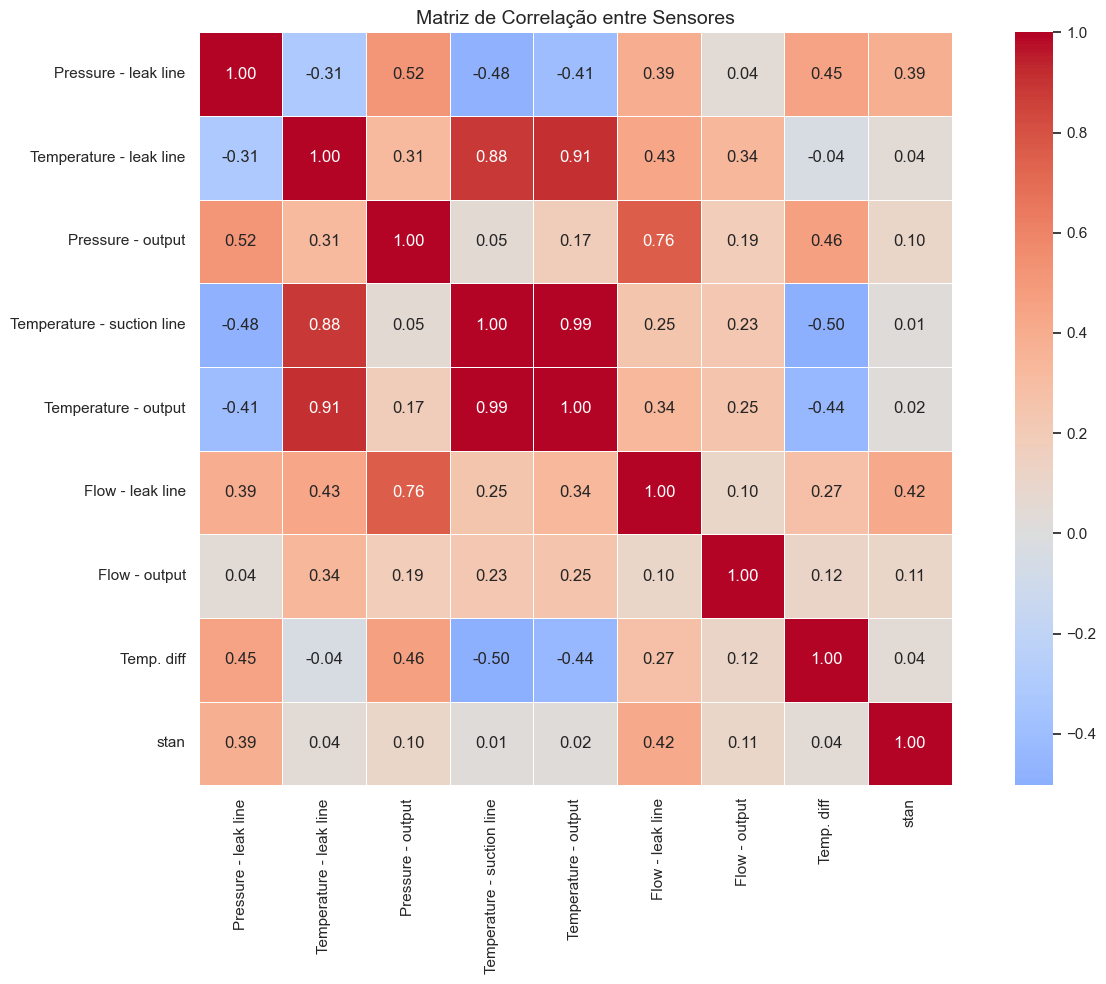


⚠️ Pares com correlação > 0.95 (possível redundância):
                     feature_1             feature_2  correlacao
31  Temperature - suction line  Temperature - output    0.992353


In [9]:

# Calcula correlação apenas entre features numéricas
# (exclui label e label_name)
corr_matrix = df[feature_cols].corr()

# --- Heatmap de correlação ---
fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,        # exibe o valor numérico em cada célula
    fmt=".2f",         # 2 casas decimais
    cmap="coolwarm",   # azul=negativo, vermelho=positivo
    center=0,          # centraliza a escala no zero
    square=True,       # células quadradas
    linewidths=0.5,
    ax=ax
)

ax.set_title("Matriz de Correlação entre Sensores", fontsize=14)
plt.tight_layout()
plt.savefig("reports/correlation_matrix.png", dpi=150)
plt.show()

# --- Identifica pares altamente correlacionados ---
# Correlação > 0.95 pode indicar features redundantes
print("\n⚠️ Pares com correlação > 0.95 (possível redundância):")
high_corr = (
    corr_matrix
    .abs()                          # valor absoluto (captura negativo também)
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # triângulo superior
    .stack()                        # transforma em Series
    .reset_index()
)
high_corr.columns = ["feature_1", "feature_2", "correlacao"]
print(high_corr[high_corr["correlacao"] > 0.95].sort_values("correlacao", ascending=False))


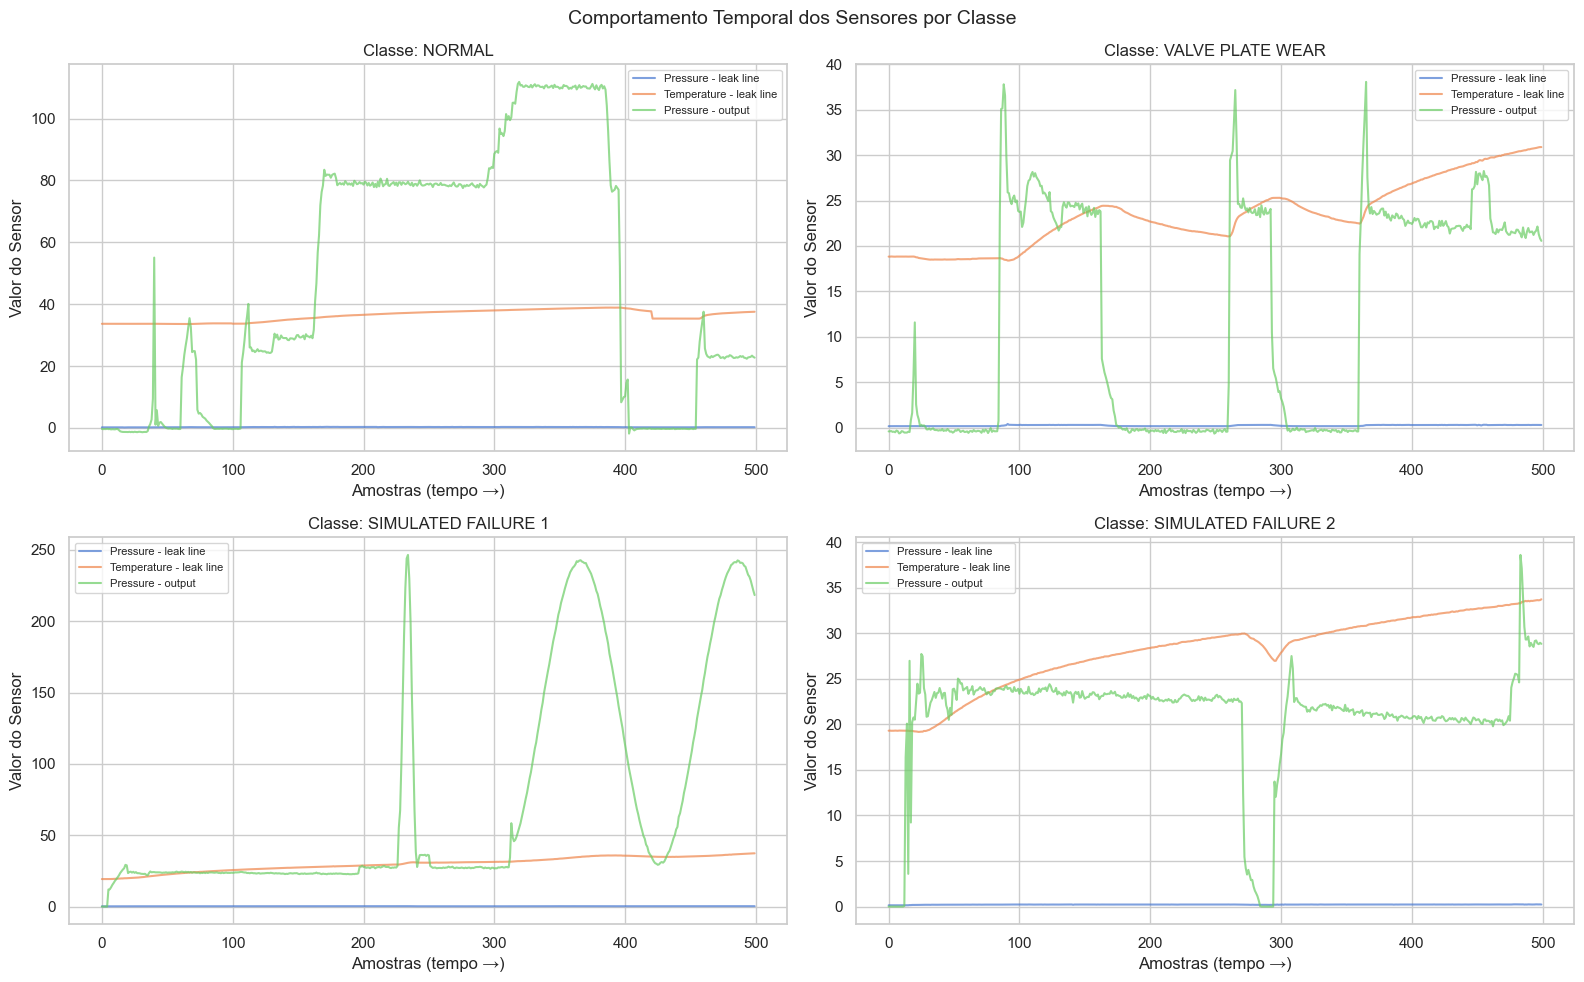

In [10]:

# Seleciona as primeiras N amostras de cada classe
# para visualizar a evolução temporal dos sensores
N = 500

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

classes = df["label_name"].unique()

for i, classe in enumerate(classes):
    subset = df[df["label_name"] == classe].head(N).reset_index(drop=True)

    # Plota os primeiros 3 sensores como exemplo
    # Troque pelos sensores mais relevantes após o Passo 3
    for sensor in feature_cols[:3]:
        axes[i].plot(subset[sensor], label=sensor, alpha=0.7)

    axes[i].set_title(f"Classe: {classe}")
    axes[i].set_xlabel("Amostras (tempo →)")
    axes[i].set_ylabel("Valor do Sensor")
    axes[i].legend(fontsize=8)

plt.suptitle("Comportamento Temporal dos Sensores por Classe", fontsize=14)
plt.tight_layout()
plt.savefig("reports/temporal_patterns.png", dpi=150)
plt.show()
